<a href="https://colab.research.google.com/github/houda21el/EDGE-KD/blob/main/MiccaiKDModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install pytorch_model_summary

In [ ]:
# !pip install torchinfo

In [ ]:
! pip uninstall opencv-python opencv-contrib-python

Found existing installation: opencv-python 4.11.0.86
Uninstalling opencv-python-4.11.0.86:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/cv2/*
    /usr/local/lib/python3.11/dist-packages/opencv_python-4.11.0.86.dist-info/*
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libQt5Core-e7f476e2.so.5.15.16
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libQt5Gui-1ce8cbfe.so.5.15.16
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libQt5Test-9ac3ed15.so.5.15.16
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libQt5Widgets-cd430389.so.5.15.16
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libQt5XcbQpa-b18b5a78.so.5.15.16
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libX11-xcb-0e257303.so.1.0.0
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libXau-00ec42fe.so.6.0.0
    /usr/local/lib/python3.11/dist-packages/opencv_python.libs/libavcodec-76c43bf0.so.59.37.100
    /usr/loca

In [ ]:
!pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 11.8 MB/s eta 0:00:00


In [ ]:
# !pip install opencv-python

In [ ]:
# !pip install --upgrade opencv-contrib-python

In [ ]:
# !pip install piqa

# Frameworks

In [ ]:
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import cv2, os, gc, glob
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split, Subset, WeightedRandomSampler
import torchvision
from torch import optim
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms, datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights, efficientnet_b0, EfficientNet_B0_Weights, mobilenet_v3_large, MobileNet_V3_Large_Weights, shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights
#from pytorch_model_summary import summary
#from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.manifold import TSNE
import warnings
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from collections import Counter
#from piqa import SSIM
import timm
from timm import create_model
from transformers import DeiTForImageClassification, DeiTConfig
from transformers import ViTForImageClassification, ViTConfig

In [ ]:
import cv2
print(cv2.__version__)


4.11.0


In [ ]:
print(dir(cv2.ximgproc))

['AM_FILTER', 'ARO_0_45', 'ARO_315_0', 'ARO_315_135', 'ARO_315_45', 'ARO_45_135', 'ARO_45_90', 'ARO_90_135', 'ARO_CTR_HOR', 'ARO_CTR_VER', 'AdaptiveManifoldFilter', 'AdaptiveManifoldFilter_create', 'BINARIZATION_NIBLACK', 'BINARIZATION_NICK', 'BINARIZATION_SAUVOLA', 'BINARIZATION_WOLF', 'ContourFitting', 'DTF_IC', 'DTF_NC', 'DTF_RF', 'DTFilter', 'DisparityFilter', 'DisparityWLSFilter', 'EDGE_DRAWING_LSD', 'EDGE_DRAWING_PREWITT', 'EDGE_DRAWING_SCHARR', 'EDGE_DRAWING_SOBEL', 'EdgeAwareInterpolator', 'EdgeBoxes', 'EdgeDrawing', 'EdgeDrawing_LSD', 'EdgeDrawing_PREWITT', 'EdgeDrawing_SCHARR', 'EdgeDrawing_SOBEL', 'FHT_ADD', 'FHT_AVE', 'FHT_MAX', 'FHT_MIN', 'FastBilateralSolverFilter', 'FastGlobalSmootherFilter', 'FastHoughTransform', 'FastLineDetector', 'GUIDED_FILTER', 'GradientDericheX', 'GradientDericheY', 'GuidedFilter', 'HDO_DESKEW', 'HDO_RAW', 'HoughPoint2Line', 'MSLIC', 'PeiLinNormalization', 'RFFeatureGetter', 'RICInterpolator', 'RadonTransform', 'RidgeDetectionFilter', 'RidgeDetect

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
  print('GPU is : {}' .format(torch.cuda.get_device_name(0)))

else:
  warnings.warn('No GPU found')

GPU is : NVIDIA L4


#Data

In [ ]:
data_dir = '/content/drive/MyDrive/Colab Notebooks/COVID-19_Radiography_Dataset'

# Define class mapping
classes = {'COVID': 'COVID', 'Normal': 'Normal', 'Viral Pneumonia': 'Viral Pneumonia', 'Lung_Opacity': 'Lung Opacity', 'TB': 'TB'}
# img_path = []
# for path, subdirs, files in os.walk(data_dir):
#   print(path, subdirs, files)
#   for name in files:
#     img_path.append(os.path.join(path, name))

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    #transforms.CenterCrop((224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
dataset = datasets.ImageFolder(data_dir, transform = transform)

In [ ]:
corrected_mapping = {'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2, 'Lung_Opacity': 3, 'TB': 4}
original_class_to_idx = dataset.class_to_idx
print("Original class_to_idx:", original_class_to_idx)
remap = {original_class_to_idx[class_name]: corrected_mapping[class_name] for class_name in original_class_to_idx}
print("Remapping des indices:", remap)

Original class_to_idx: {'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'TB': 3, 'Viral Pneumonia': 4}
Remapping des indices: {0: 0, 1: 3, 2: 1, 3: 4, 4: 2}


In [ ]:
indices = list(range(len(dataset)))
labels = [remap[dataset.samples[i][1]] for i in indices]
print("Distribution des labels corrigés :", Counter(labels))

Distribution des labels corrigés : Counter({1: 10192, 3: 6012, 0: 3616, 4: 2494, 2: 1345})


In [ ]:
TrainX, ValX = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
ValX, TestX = train_test_split(ValX, test_size=0.5, stratify=[labels[i] for i in ValX], random_state=42)

In [ ]:
Train_Data = Subset(dataset, TrainX)
Val_Data = Subset(dataset, ValX)
Test_Data = Subset(dataset, TestX)

In [ ]:
# Vérifier la distribution des classes dans les subsets
train_labels = [labels[i] for i in TrainX]
test_labels = [labels[i] for i in TestX]

print("Distribution des classes dans l'entraînement :", Counter(train_labels))
print("Distribution des classes dans le test :", Counter(test_labels))

Distribution des classes dans l'entraînement : Counter({1: 7134, 3: 4208, 0: 2531, 4: 1746, 2: 942})
Distribution des classes dans le test : Counter({1: 1529, 3: 902, 0: 543, 4: 374, 2: 201})


In [ ]:
label_counts = Counter(labels)
total_samples = sum(label_counts.values())
class_weights = {class_idx: total_samples / count for class_idx, count in label_counts.items()}

In [ ]:
# Assign weights to each sample in the training set
sample_weights = [class_weights[labels[i]] for i in TrainX]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [ ]:
batch_size = 64
train_loader = DataLoader(Train_Data, batch_size=batch_size, sampler=sampler, num_workers=8)
val_loader = DataLoader(Val_Data, batch_size=batch_size, shuffle=False, num_workers=8)
test_loader = DataLoader(Test_Data, batch_size=batch_size, shuffle=False, num_workers=4)

# initialisation

In [ ]:
num_classes = 5
learning_rate = 0.001
class_weights_tensor = torch.tensor([class_weights[class_idx] for class_idx in range(len(label_counts))], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [ ]:
class ModelFeatures(nn.Module):
    def __init__(self, model, num_classes, input_size=(3, 224, 224)):
        super(ModelFeatures, self).__init__()

        self.backbone = model  # Store the full backbone
        self.use_cls_token = False  # For ViT-like models

        # Determine feature dimensions
        if hasattr(model, "base_model") and hasattr(model, "classifier"):  # Hugging Face DeiT
            self.features = model.base_model
            self.use_cls_token = True
            in_features = model.classifier.in_features

        elif hasattr(model, "features") and hasattr(model, "head"):  # Torchvision ViT
            self.features = model.features
            self.use_cls_token = True
            in_features = model.head.in_features

        elif hasattr(model, "forward_features"):  # timm Transformers
            self.features = model.forward_features
            self.use_cls_token = True
            with torch.no_grad():
                dummy_input = torch.randn(1, *input_size).to(next(model.parameters()).device)
                dummy_output = self.features(dummy_input)
                in_features = dummy_output.shape[-1] if len(dummy_output.shape) == 2 else dummy_output.shape[1]

        elif hasattr(model, "fc"):  # CNNs like ResNet
            self.features = nn.Sequential(*list(model.children())[:-1], nn.Flatten())
            with torch.no_grad():
                dummy_input = torch.randn(1, *input_size).to(next(model.parameters()).device)
                dummy_output = self.features(dummy_input)
                in_features = dummy_output.shape[-1]

        elif hasattr(model, "classifier"):  # MobileNet/EfficientNet
            self.features = nn.Sequential(*list(model.children())[:-1], nn.Flatten())
            with torch.no_grad():
                dummy_input = torch.randn(1, *input_size).to(next(model.parameters()).device)
                dummy_output = self.features(dummy_input)
                in_features = dummy_output.shape[-1]
        # Check for torchvision ViT architecture by checking for 'encoder' attribute.
        elif hasattr(model, 'encoder'):  # ViT models
            self.features = model.encoder
            self.use_cls_token = True  # ViT uses [CLS] token

            # Get the input features for the classifier
            # from the last layer of the encoder
            in_features = model.heads.head.in_features
        else:
            raise ValueError("Unsupported model architecture")

        # Define the classifier
        self.classifier = nn.Sequential(
            #nn.Dropout(p=0.33),  # Optional dropout
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
      # add to train the vitbase16
        if hasattr(self.backbone, 'patch_embed'):
            x = self.backbone.patch_embed(x)

        # Pass through the feature extractor
        x = self.features(x)

        # Handle [CLS] token for Transformers
        if self.use_cls_token and isinstance(x, torch.Tensor) and len(x.shape) == 3:
            x = x[:, 0, :]  # Extract [CLS] token for classification

        # Flatten to 2D if needed (for CNNs)
        x = x.view(x.size(0), -1)
        logit = self.classifier(x)
        return logit

In [ ]:
def train_student_with_kd(studentKd_model, teacher_model, train_loader, val_loader, criterion_kd, optimizer, device, num_epochs):
    best_acc = 0.0
    best_loss = float('inf')
    best_wts = copy.deepcopy(studentKd_model.state_dict())
    history_Kd = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    teacher_model.eval()
    for param in teacher_model.parameters():
        param.requires_grad = False

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        studentKd_model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc='Training Student with KD'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion_kd.compute_total_loss(inputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(studentKd_model.parameters(), max_norm=0.2)
            optimizer.step()

            with torch.no_grad():
                student_logits = studentKd_model(inputs)
                _, preds = torch.max(student_logits, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)


        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history_Kd['train_loss'].append(epoch_loss)
        history_Kd['train_acc'].append(epoch_acc.item())

        print(f'Training Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

        test_loss, test_acc, _, _ = evaluate_model(studentKd_model, val_loader, device, nn.CrossEntropyLoss(weight=class_weights_tensor))
        history_Kd['test_loss'].append(test_loss)
        history_Kd['test_acc'].append(test_acc)
        print(f"Validation Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

        #scheduler.step(test_loss)

        if test_acc > best_acc:
            best_acc = test_acc
            best_loss = test_loss
            best_wts = copy.deepcopy(studentKd_model.state_dict())

    print(f'Best student with KD: Validation Accuracy: {best_acc:.4f}, Validation Loss: {best_loss:.4f}')
    studentKd_model.load_state_dict(best_wts)
    #torch.save(studentKd_model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/MODEL_KD/OwnerEffB0M1.pth')

    return studentKd_model, history_Kd

## evaluating def

In [ ]:
def evaluate_model(model, data_loader, device, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            _, preds = torch.max(logits, 1)
            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    return avg_loss, acc, all_preds, all_labels

## test def

In [ ]:
def test_model(model, dataTest, criterion, device):
    model.eval()

    run_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
      for inputs, labels in tqdm(dataTest, desc="Test"):
        inputs, labels = inputs.to(device), labels.to(device)

        logits = model(inputs)
        loss = criterion(logits, labels)

        _, preds = torch.max(logits, 1)
        run_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    loss_t = run_loss / len(dataTest.dataset)
    acc_t = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    return loss_t, acc_t

In [ ]:
def evaluate_model_roc(model, data_loader, device, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc='Evaluating'):
            inputs, labels = inputs.to(device), labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)  # Convert logits to probabilities
            _, preds = torch.max(probs, 1)  # Get predicted class labels
            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(data_loader.dataset)
    acc = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    return avg_loss, acc, all_preds, all_labels, np.array(all_probs)

# KD  with TS-EXM

In [ ]:
class TS_EXM:
    def __init__(self, layers, num_features_list, sigma):

        self.layers = layers
        self.num_features_list = num_features_list
        self.sigma = sigma

    def register_hooks(self, model):

        intermediate_outputs = []
        hooks = []

        def hook_fn(module, input, output):
            intermediate_outputs.append(output)

        for layer_name in self.layers:
            layer = dict(model.named_modules())[layer_name]
            hook = layer.register_forward_hook(hook_fn)
            hooks.append(hook)

        return hooks, intermediate_outputs

    def extract_saliency_maps(self, model, images):

        hooks, intermediate_outputs = self.register_hooks(model)
        model(images)
        both_features = [intermediate_outputs[0], intermediate_outputs[-1]]

        importance_maps = self._MOWNER1(images, both_features, self.num_features_list, self.sigma)


        for hook in hooks:
            hook.remove()
        return importance_maps

    def fuse_maps(self, importance_map1, importance_map2):

      height, width = importance_map1.shape[:2]
      importance_map2 = cv2.resize(importance_map2, (width, height), interpolation=cv2.INTER_LINEAR)

      # verify that the  importance_map1 has a type of float32 and has 3 channels(RGB)
      importance_map1 = importance_map1.astype(np.float32)
      if importance_map1.ndim == 3 and importance_map1.shape[2] > 3:
          importance_map1 = importance_map1[:, :, :3]  # take the 3

      # be sure importance_map2 has type float32 and has 3  channels
      importance_map2 = importance_map2.astype(np.float32)
      if importance_map2.ndim == 3 and importance_map2.shape[2] > 3:
          importance_map2 = importance_map2[:, :, :3]

      radius = 5
      eps = 1e-6
      importance_map_fused = cv2.ximgproc.guidedFilter(
          importance_map1, importance_map2, radius, eps
      )

      importance_map_fused = (importance_map_fused - importance_map_fused.min()) / (
          importance_map_fused.max() - importance_map_fused.min()
      )
      return importance_map_fused

    def _MOWNER1(self, image, Layers_name, num_features_list, sigma=1):
        importance_saliency_maps = []

        for feature_maps, num_features in zip(Layers_name, num_features_list):
            feature_maps_mean = feature_maps.mean(dim=(0, 2, 3))  # Global average
            top_indices = torch.argsort(feature_maps_mean, descending=True)[:num_features]
            feature_maps = feature_maps[:, top_indices, :, :]

            means = feature_maps.mean(dim=(0, 2, 3))
            stds = feature_maps.std(dim=(0, 2, 3))

            binary_maps = []
            for i in range(feature_maps.shape[1]):
                binary_map = torch.zeros_like(feature_maps[:, i, :, :])
                binary_map[feature_maps[:, i, :, :] > means[i] + sigma * stds[i]] = 1
                binary_maps.append(binary_map)

            weights = means / means.sum()
            i_map = torch.zeros_like(feature_maps[:, 0, :, :])

            for i, binary_map in enumerate(binary_maps):
                i_map += binary_map * weights[i]

            # Normalize and resize
            s_map = (i_map - i_map.min()) / (i_map.max() - i_map.min())
            original_size = image.shape[2:]

            if s_map.dim() == 3:  # verify the dimension
                s_map = s_map.unsqueeze(0)
            if s_map.shape[-2:] != original_size:
                s_map = F.interpolate(
                    s_map, size=original_size, mode="bilinear", align_corners=False
                )
            is_map = s_map.squeeze().detach().cpu().numpy() #s_map.squeeze().cpu().numpy()
            importance_saliency_maps.append(is_map)

        return importance_saliency_maps


## KDexm

In [ ]:
class KnowledgeDistillationEXM:
    def __init__(self, teacher_model, student_model, ts_exm_t, ts_exm_s, alpha):
        self.teacher_model = teacher_model
        self.student_model = student_model
        self.ts_exm_t = ts_exm_t
        self.ts_exm_s = ts_exm_s
        self.alpha = alpha
        #self.ce_loss_fn = nn.CrossEntropyLoss()
        self.ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

    def compute_saliency_loss(self, teacher_map, student_map):

        teacher_map_tensor = torch.tensor(teacher_map, dtype=torch.float32, device="cuda")
        student_map_tensor = torch.tensor(student_map, dtype=torch.float32, device="cuda")
        return torch.mean((teacher_map_tensor - student_map_tensor) ** 2)

    def logit_loss(self, teacher_logit, student_logit):

        teacher_probs = F.softmax(teacher_logit, dim=1)
        student_probs = F.softmax(student_logit, dim=1)
        return F.mse_loss(student_probs, teacher_probs)



    def compute_total_loss(self, images, labels):

        with torch.no_grad():
            teacher_logits = self.teacher_model(images)
        student_logits = self.student_model(images)
        # Compute predictive loss alignment
        pd_loss = self.logit_loss(teacher_logits, student_logits)

        # Compute CE loss
        ce_loss = self.ce_loss_fn(student_logits, labels)

        # Extract saliency maps
        teacher_maps = self.ts_exm_t.extract_saliency_maps(self.teacher_model, images)
        student_maps = self.ts_exm_s.extract_saliency_maps(self.student_model, images)

        # Fuse saliency maps
        fused_teacher_map = self.ts_exm_t.fuse_maps(teacher_maps[0], teacher_maps[1])
        fused_student_map = self.ts_exm_s.fuse_maps(student_maps[0], student_maps[1])
        #print(fused_student_map)
        #print(fused_teacher_map)
        # Compute saliency loss
        saliency_loss = self.compute_saliency_loss(fused_teacher_map, fused_student_map)
        #print(saliency_loss)
        # Total loss
        total_loss = self.alpha * (saliency_loss+ pd_loss) + (1-self.alpha)*ce_loss
        return total_loss


# Main

## EfficientNetB0

In [ ]:
teacher = models.efficientnet_v2_s(weights='EfficientNet_V2_S_Weights.DEFAULT')
teacher_model = ModelFeatures(teacher, num_classes=len(classes)).to(device)
teacher_model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/MODEL_KD/EffV2Steacher.pth'), strict=False)

<ipython-input-24-af778dcf9eb3>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher_model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/MODEL_KD/Ef

_IncompatibleKeys(missing_keys=['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'backbone.features.1.0.block.0.0.weight', 'backbone.features.1.0.block.0.1.weight', 'backbone.features.1.0.block.0.1.bias', 'backbone.features.1.0.block.0.1.running_mean', 'backbone.features.1.0.block.0.1.running_var', 'backbone.features.1.1.block.0.0.weight', 'backbone.features.1.1.block.0.1.weight', 'backbone.features.1.1.block.0.1.bias', 'backbone.features.1.1.block.0.1.running_mean', 'backbone.features.1.1.block.0.1.running_var', 'backbone.features.2.0.block.0.0.weight', 'backbone.features.2.0.block.0.1.weight', 'backbone.features.2.0.block.0.1.bias', 'backbone.features.2.0.block.0.1.running_mean', 'backbone.features.2.0.block.0.1.running_var', 'backbone.features.2.0.block.1.0.weight', 'backbone.features.2.0.block.1.1.weight', 'backbone.features.2.0.block.1.1.bias', 'backbone.features

In [ ]:
student = models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
student_model = ModelFeatures(student, num_classes=len(classes)).to(device)
optimizer_student = optim.SGD(student_model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-3)

In [ ]:
ts_exm_t = TS_EXM(
    layers=['backbone.features.4.0.block.2', 'backbone.features.6.10.block.2'],
    num_features_list=[36, 46],
    sigma=1
)
ts_exm_s=TS_EXM(
    layers=['backbone.features.4.0.block.2', 'backbone.features.5.0.block.2'],
    num_features_list=[36, 46],
    sigma=1
)

In [ ]:
kd_criterion = KnowledgeDistillationEXM(
    teacher_model=teacher_model,
    student_model=student_model,
    ts_exm_t=ts_exm_t,
    ts_exm_s = ts_exm_s,
    alpha=0.4,
)


In [ ]:
student_model_kd, student_kd_history = train_student_with_kd(
        studentKd_model=student_model,
        teacher_model=teacher_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion_kd=kd_criterion,
        optimizer=optimizer_student,
        device=device,
        num_epochs=50
    )


Epoch 1/50


Training Student with KD: 100%|██████████| 259/259 [04:38<00:00,  1.07s/it]


Training Loss: 0.6263, Accuracy: 0.4069


Evaluating: 100%|██████████| 56/56 [00:24<00:00,  2.32it/s]


Validation Loss: 0.6867, Accuracy: 0.4376
Epoch 2/50


...

Validation Loss: 0.0949, Accuracy: 0.9355
Epoch 50/50


Training Student with KD: 100%|██████████| 259/259 [04:12<00:00,  1.02it/s]


Training Loss: 0.0696, Accuracy: 0.9504


Evaluating: 100%|██████████| 56/56 [00:24<00:00,  2.32it/s]


Validation Loss: 0.0922, Accuracy: 0.9411
Best student with KD: Validation Accuracy: 0.9465, Validation Loss: 0.0954


In [ ]:
test_acc, test_loss = test_model(student_model_kd, test_loader, criterion, device)
print('test accuracy is', test_acc)
print('test loss is', test_loss)

Test: 100%|██████████| 56/56 [00:23<00:00,  2.43it/s]

test accuracy is 0.08477967265005615
test loss is 0.9459002535925612


In [ ]:
test_acc, test_loss = test_model(student_model_kd, test_loader, criterion, device)
print('test accuracy is', test_acc)
print('test loss is', test_loss)

Test: 100%|██████████| 56/56 [00:09<00:00,  5.96it/s]

test accuracy is 0.09898436975671426
test loss is 0.9489997182304875


# Learning curve

In [ ]:
def plot_learning_curve(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['test_loss'], label='Test Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['test_acc'], label='Test Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Generate classification report
def generate_classification_report(model, data_loader, device, class_names, title):
    _, _, all_preds, all_labels = evaluate_model(model, data_loader, device, nn.CrossEntropyLoss())
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print(f'{title} - Classification Report:\n{report}')

## EfficientnetB0

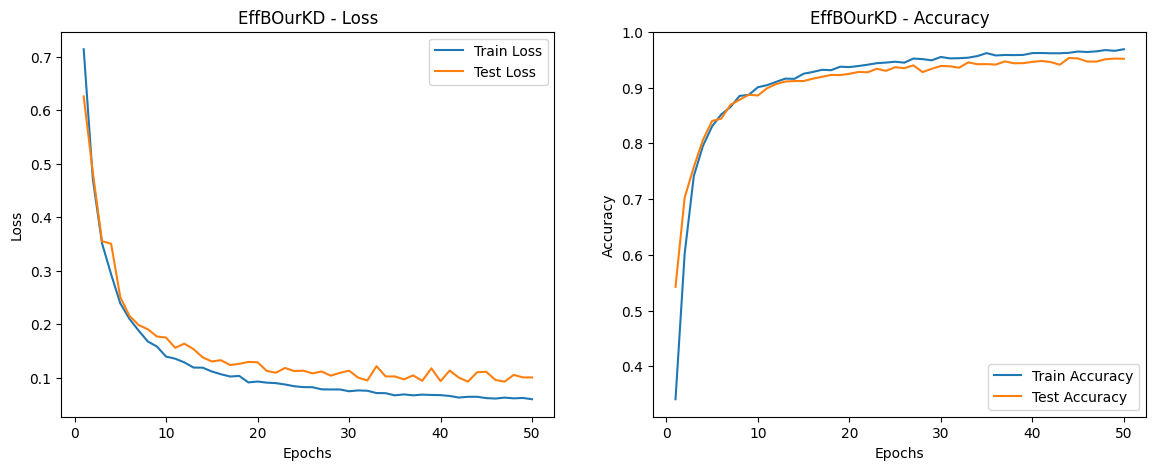

In [ ]:
plot_learning_curve(student_kd_history, 'EffBOurKD')

In [ ]:
generate_classification_report(student_model_kd, test_loader, device, list(classes.values()), 'EffBOurKD')

Evaluating: 100%|██████████| 56/56 [00:23<00:00,  2.41it/s]

EffBOurKD - Classification Report:
                 precision    recall  f1-score   support

          COVID     0.9720    0.9576    0.9647       543
         Normal     0.9645    0.8437    0.9001       902
Viral Pneumonia     0.9143    0.9836    0.9477      1529
   Lung Opacity     0.9947    0.9973    0.9960       374
             TB     0.9707    0.9900    0.9803       201

       accuracy                         0.9459      3549
      macro avg     0.9632    0.9545    0.9578      3549
   weighted avg     0.9475    0.9459    0.9451      3549



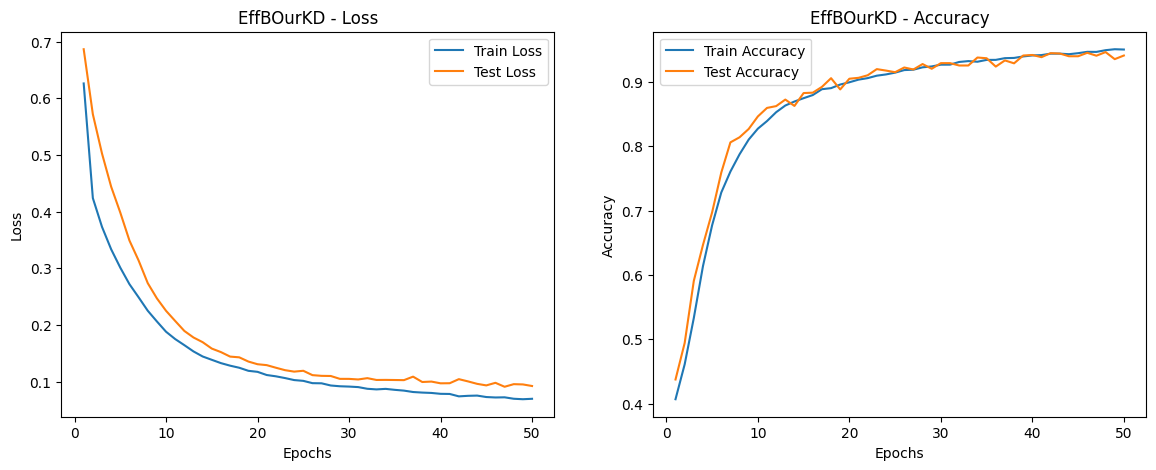

In [ ]:
plot_learning_curve(student_kd_history, 'EffBOurKD')

In [ ]:
generate_classification_report(student_model_kd, test_loader, device, list(classes.values()), 'EffBOurKD')

Evaluating: 100%|██████████| 56/56 [00:28<00:00,  1.95it/s]

EffBOurKD - Classification Report:
                 precision    recall  f1-score   support

          COVID     0.9850    0.9669    0.9758       543
         Normal     0.9524    0.8880    0.9191       902
Viral Pneumonia     0.9329    0.9725    0.9523      1529
   Lung Opacity     1.0000    1.0000    1.0000       374
             TB     0.9662    0.9950    0.9804       201

       accuracy                         0.9544      3549
      macro avg     0.9673    0.9645    0.9655      3549
   weighted avg     0.9548    0.9544    0.9541      3549



# Confusion matrix

In [ ]:
def conMatrix(model, data, title, device):
    class_names = ['C', 'N', 'V_P', 'L_O', 'TB']

    _, _, all_preds, all_labels = evaluate_model(model, data, device, nn.CrossEntropyLoss())
    cm = confusion_matrix(all_labels, all_preds)

    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Create a DataFrame for better labeling
    df_cm_percentage = pd.DataFrame(cm_percentage, index=class_names, columns=class_names)


    plt.figure()
    sns.heatmap(df_cm_percentage, annot=True, fmt='.2%', cmap='Blues', cbar=False,
                annot_kws={"size": 12})

    plt.title(f'{title} - Confusion Matrix', fontsize=12)

    plt.show()

## EfficientnetB0

Evaluating:   0%|          | 0/56 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Evaluating: 100%|██████████| 56/56 [00:26<00:00,  2.13it/s]


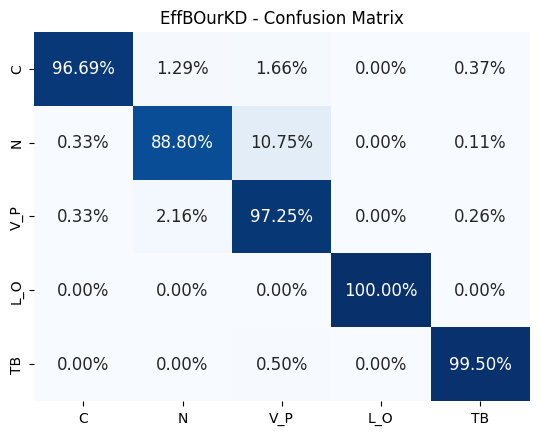

In [ ]:
conMatrix(student_model_kd, test_loader, 'EffBOurKD', device)